In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [39]:
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")
print(df.shape)
print(df.head())
print(df.tail())

(100, 6)
          x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
0 -1.000000  11.624419   8.296963  12.201067   7.811725   3.155566
1 -0.929293  10.377466   9.674440  12.198084   8.275006   7.518855
2 -0.858586  10.585100   9.251983  13.186565  12.926586   9.963630
3 -0.787879  10.913928   7.786344  12.552304  11.832379   9.625801
4 -0.717172   8.640287   8.551869   4.741432   8.790834   6.624113
           x  y_noise_1  y_noise_2  y_noise_3  y_noise_4  y_noise_5
95  5.717172  -1.411918   0.822231  -2.027132  -1.825106   2.746147
96  5.787879   0.344879  -1.718956   2.747559  -6.803779  -5.137472
97  5.858586   0.307133   0.353528   0.967976   5.461567  -0.905616
98  5.929293   0.048657   0.159961   2.482130  -0.414616  -4.334548
99  6.000000  -0.193438  -2.244792   1.930035   4.992414  -6.872850


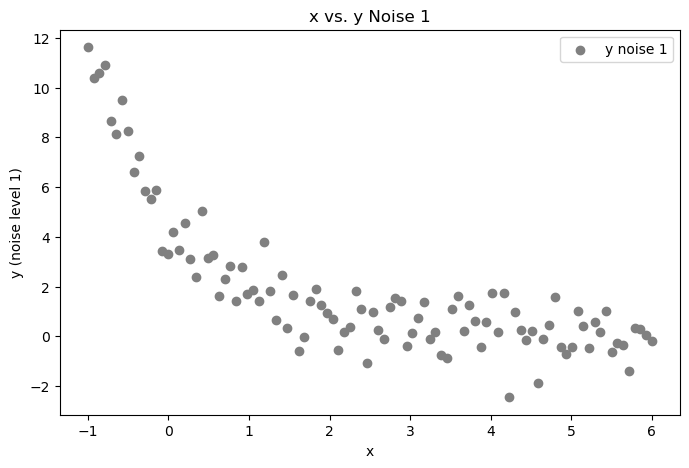

In [40]:
plt.figure(figsize=(8,5))

plt.scatter(df["x"], df["y_noise_1"], color='gray', label='y noise 1')

plt.xlabel("x")
plt.ylabel("y (noise level 1)")
plt.title("x vs. y Noise 1")
plt.legend()
plt.show()

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi-squared: 0.79


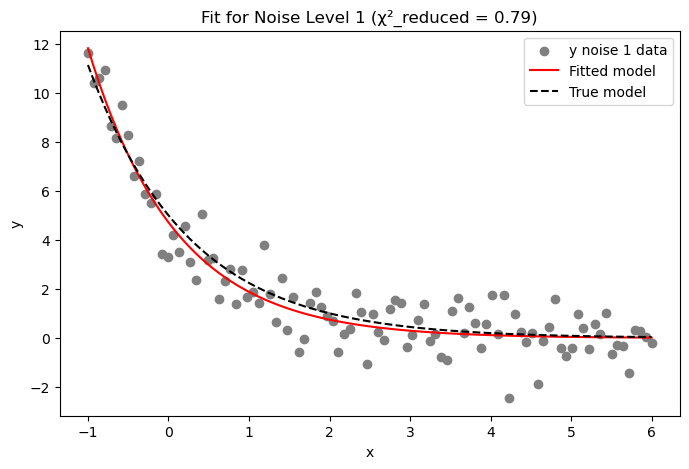

In [41]:
x = df["x"].values
y_noise_1 = df["y_noise_1"].values

def model(x, A, k):
    return A * np.exp(-k * x)

p0 = [1, 1]
popt, pcov = curve_fit(model, x, y_noise_1, p0=p0)

A_fit, k_fit = popt

print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")

residuals = y_noise_1 - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof

print(f"Reduced chi-squared: {chi2_reduced:.2f}")

plt.figure(figsize=(8,5))

plt.scatter(x, y_noise_1, color='gray', label='y noise 1 data')
plt.plot(x, model(x, A_fit, k_fit), color='red', label='Fitted model')
plt.plot(x, model(x, 5, 0.8), color='black', linestyle='--', label='True model')
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Fit for Noise Level 1 (χ²_reduced = {chi2_reduced:.2f})")
plt.legend()

plt.show()


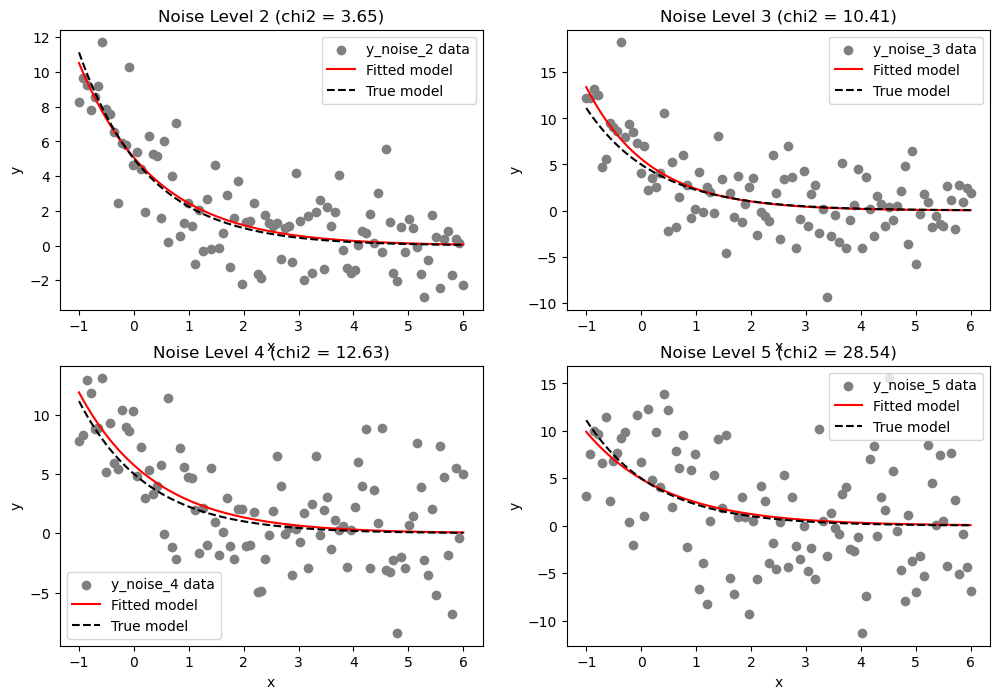

In [42]:
# 2.3

def fit_model(x, y):
    p0 = [1, 1]
    popt, pcov = curve_fit(model, x, y, p0=p0)

    A_fit, k_fit = popt

    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced = chi2 / dof

    return A_fit, k_fit, chi2_reduced

noise_columns = ["y_noise_2", "y_noise_3", "y_noise_4", "y_noise_5"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col in zip(axes.flatten(), noise_columns):
    y = df[col].values

    A_fit, k_fit, chi2_reduced = fit_model(x, y)

    ax.scatter(x, y, color="gray", label=f"{col} data")

    ax.plot(x, model(x, A_fit, k_fit), color="red", label="Fitted model")

    ax.plot(x, model(x, 5, 0.8), "k--", label="True model")

    noise_level = col[-1] 
    ax.set_title(f"Noise Level {noise_level} (chi2 = {chi2_reduced:.2f})")

    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.legend()

plt.show()


In [43]:
# Q1:
# As the noise level increases, the red fitted model begins to deviate more from the black true model, because noise masks the real trend.
# Q2:
# As noise increases, the reduced chi-squared increases, because the residuals get larger when noise is higher. The sum of squared residuals increases and the chi2 value increases.

In [44]:
noise_columns = [
    "y_noise_1",
    "y_noise_2",
    "y_noise_3",
    "y_noise_4",
    "y_noise_5"
]

rows = []

for col in noise_columns:
    y = df[col].values
    A_fit, k_fit, chi2_reduced = fit_model(df["x"].values, y)

    rows.append({
        "Noise level": col[-1],
        "A fit": A_fit,
        "k fit": k_fit,
        "Reduced chi-squared": chi2_reduced
    })

df_params = pd.DataFrame(rows)
df_params

,Noise level,A fit,k fit,Reduced chi-squared
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [45]:
df_params.to_csv("noisy_parameters.csv", index=False)